# **AI Advanced Ahmed Yousrey Course Practice**

---
# **DAY 9 — Arabic Document Intelligence**
---

# **STEP 1 - IMPORT LIBRARIES**

---

In [33]:
!pip install -q transformers datasets evaluate accelerate


import pandas as pd
import numpy as np

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

import evaluate

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")


## **STEP 2 - LOAD DATA**

---

In [4]:
file_path = "/kaggle/input/datasets/mohamedramadan2040/arabic-customer-reviews/Final_Data.csv"

df = pd.read_csv(file_path)

## **STEP 3 - EDA**

---

In [6]:
df.head()

,review_description,rating,company
0,رائع,positive,talbat
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,positive,talbat
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,negative,talbat
3,لماذا لا يمكننا طلب من ماكدونالدز؟,negative,talbat
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,negative,talbat


In [7]:
print("Shape:", df.shape)

Shape: (40046, 3)


In [10]:
df.describe()


,review_description,rating,company
count,40045,40046,40046
unique,39003,3,12
top,ممتاز,positive,talbat
freq,16,23921,32073


In [9]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
review_description    1
rating                0
company               0
dtype: int64


In [12]:
for col in df.columns:
    
    print(df[col].value_counts(dropna=False).head(10))

review_description
ممتاز        16
رائع         13
جيد          11
ممتازه       11
جيد جدا      11
جميل          9
جميل جدا      8
ممتاز جدا     8
تم            7
ممتازة        7
Name: count, dtype: int64
rating
positive    23921
negative    14200
neutral      1925
Name: count, dtype: int64
company
talbat           32073
swvl              4693
telecom_egypt     2090
venus              281
Raya               268
TMG                250
elsewedy           147
hilton             100
capiter             73
Ezz Steel           49
Name: count, dtype: int64


In [13]:
# Target distribution
rating_counts = df["rating"].value_counts()
rating_percentages = df["rating"].value_counts(normalize=True) * 100

distribution = pd.DataFrame({
    "Count": rating_counts,
    "Percentage": rating_percentages.round(2)
})

print(distribution)

          Count  Percentage
rating                     
positive  23921       59.73
negative  14200       35.46
neutral    1925        4.81


In [15]:
print("Number of reviews:", len(df))

print("\nText length statistics:")
df["review_length"] = df["review_description"].astype(str).str.split().str.len()

print(df["review_length"].describe())

Number of reviews: 40046

Text length statistics:
count    40046.000000
mean         9.370774
std         12.527072
min          1.000000
25%          3.000000
50%          5.000000
75%         11.000000
max        443.000000
Name: review_length, dtype: float64


In [16]:
display(
    df[["review_description", "rating"]]
    .sample(10, random_state=42)
)

,review_description,rating
19292,اهنئكم على خدمه العملاء في المحادثه المباشره م...,positive
24156,ممتاز جدا ولكن اتمنى ان تكون هناك بعض المسابقا...,positive
29442,كل محملته يقول تم ايقاف حطيت2 عشان تسوون الخطاء,negative
10365,شغل طيب,positive
7401,بعد ماجربت,positive
6885,وايد زين,positive
314,سيئ جدا جدا,negative
36959,تطبيق ضعيف لا يليق بشركه كبيره مثل رأيه واغلب ...,negative
12146,٠ ٠ؤ٩,negative
32965,السواقين بيكدبوا ومبيجوش وبيكنسلوا الرحلات مع ...,negative


In [17]:
display(
    df[["review_description", "rating", "review_length"]]
    .sort_values("review_length", ascending=False)
    .head(10)
)

,review_description,rating,review_length
39652,الي/ السيد الاستاذ رئيس مجلس إدارة شركة طلعت م...,negative,443
39622,ارجوا من سيادتكم التفضل بقراءة هذه السطورالموج...,positive,374
39918,امبارح بعد نص الليل كنت راجعة من الساحل المفرو...,negative,368
22286,خارا خرا خرا خرا خرا خرا خرا خرا خرا خرا خرا خ...,negative,258
39618,عندهم امكانيات تخليهم احسن مطور عقاري في مصر و...,negative,235
8609,تطبيق لا ينتمي للمصاقيه باي شكل نصابين وعلى عي...,negative,193
39914,\nمؤخرا بقى زي الزفت حقيقي\n:اخر مواقف اتعرضتل...,negative,161
36363,الخدمة كويسة جدا بس ملاحظاتي 1/الخطوط محدودة ن...,positive,135
39919,\nكنت حاجزه معاهم كرسين و مسافره عشان معاد دكت...,negative,120
39625,بصراحه مايستهلوش ولا نجمه معامله سيئه من كافة ...,negative,118


## **STEP 4 - PREPROCESSING**

---

remove null values

In [19]:
df = df.dropna(subset=["review_description"]).reset_index(drop=True)

print(df.shape)
print(df.isnull().sum())

(40045, 4)
review_description    0
rating                0
company               0
review_length         0
dtype: int64


---
split data 

In [21]:
X = df["review_description"]
y = df["rating"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [22]:
print("Train:", len(X_train))
print("Validation:", len(X_valid))
print("Test:", len(X_test))

Train: 32036
Validation: 4004
Test: 4005


In [23]:
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nValidation distribution:")
print(y_valid.value_counts(normalize=True).mul(100).round(2))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))


Train distribution:
rating
positive    59.74
negative    35.46
neutral      4.81
Name: proportion, dtype: float64

Validation distribution:
rating
positive    59.74
negative    35.46
neutral      4.80
Name: proportion, dtype: float64

Test distribution:
rating
positive    59.73
negative    35.46
neutral      4.82
Name: proportion, dtype: float64


---
label the string datatype

In [24]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

In [25]:
y_train = y_train.map(label2id)
y_valid = y_valid.map(label2id)
y_test = y_test.map(label2id)

In [26]:
print(y_train.head())
print(y_train.value_counts().sort_index())

4200     2
34586    2
14408    2
4905     2
28159    0
Name: rating, dtype: int64
rating
0    11359
1     1540
2    19137
Name: count, dtype: int64


In [27]:
train_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

valid_df = pd.DataFrame({
    "text": X_valid.values,
    "label": y_valid.values
})

test_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test.values
})

In [30]:
display(train_df.head())

,text,label
0,تجربه جميله وتطبيق ممتاز,2
1,شركة محترمة جدا ومشروع ناجح,2
2,ممتاااااااااااز,2
3,Great application good luke ♡,2
4,واااااااااأااأااااو,0


---
## **STEP 5 - Hugging Face**

---

arabic model

In [31]:
MODEL_NAME = "CAMeL-Lab/bert-base-arabic-camelbert-mix"

---
load the AutoTokenizer

In [34]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [35]:
text = train_df["text"].iloc[0]

print("Original text:")
print(text)

tokens = tokenizer.tokenize(text)

print("\nTokens:")
print(tokens)

Original text:
تجربه جميله وتطبيق ممتاز

Tokens:
['تجربه', 'جميله', 'وتطبيق', 'ممتاز']


In [37]:
encoded = tokenizer(text)

print("Input IDs:")
print(encoded["input_ids"])

print("\nAttention Mask:")
print(encoded["attention_mask"])

Input IDs:
[2, 18306, 5334, 22733, 9513, 3]

Attention Mask:
[1, 1, 1, 1, 1, 1]


---
create a function to redo the last step on the whole dataset

In [38]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [39]:
print(tokens)
print(encoded)

['تجربه', 'جميله', 'وتطبيق', 'ممتاز']
{'input_ids': [2, 18306, 5334, 22733, 9513, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}


In [40]:
train_dataset = Dataset.from_pandas(train_df)
valid_dataset = Dataset.from_pandas(valid_df)
test_dataset = Dataset.from_pandas(test_df)

In [43]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
valid_dataset = valid_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/32036 [00:00<?, ? examples/s]

Map:   0%|          | 0/4004 [00:00<?, ? examples/s]

Map:   0%|          | 0/4005 [00:00<?, ? examples/s]

In [45]:
print(train_dataset)
print("*"*50)
print(train_dataset[0])

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 32036
})
**************************************************
{'text': 'تجربه جميله وتطبيق ممتاز', 'label': 2, 'input_ids': [2, 18306, 5334, 22733, 9513, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [46]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

---
load the CAMeLBERT model

In [47]:

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; n

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

In [48]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [49]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro")
    }

In [50]:

training_args = TrainingArguments(
    output_dir="./camelbert_results",

    num_train_epochs=2,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_steps=100,
    report_to="none"
)

In [51]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [52]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.782293,0.789404,0.863886,0.595557
2,0.668905,0.792188,0.864885,0.629929


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

In [53]:
test_results = trainer.evaluate(test_dataset)

print(test_results)

{'eval_loss': 0.7822086215019226, 'eval_accuracy': 0.866916354556804, 'eval_f1_macro': 0.6330116874335942, 'eval_runtime': 17.5824, 'eval_samples_per_second': 227.785, 'eval_steps_per_second': 3.583, 'epoch': 2.0}


---
## **STEP 6 - classification report and confusion matrix**

In [54]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    )
)

              precision    recall  f1-score   support

    negative       0.84      0.87      0.85      1420
     neutral       0.36      0.08      0.13       193
    positive       0.89      0.93      0.91      2392

    accuracy                           0.87      4005
   macro avg       0.70      0.63      0.63      4005
weighted avg       0.85      0.87      0.85      4005



In [55]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[1239    6  175]
 [  89   16   88]
 [ 152   23 2217]]


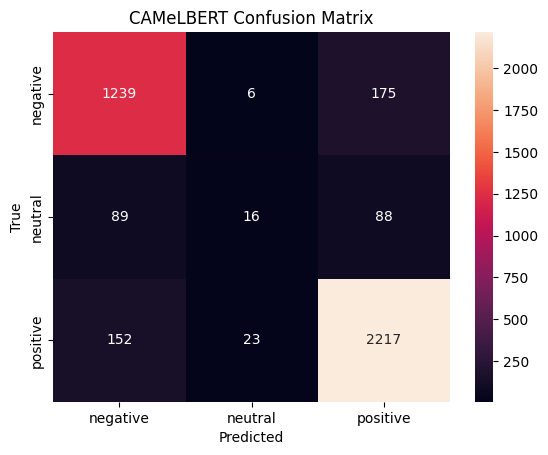

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CAMeLBERT Confusion Matrix")
plt.show()

---
inspect the actual mistakes

In [57]:
error_df = test_df.copy()

error_df["true_label"] = y_true
error_df["predicted_label"] = y_pred

neutral_errors = error_df[
    (error_df["true_label"] == 1) &
    (error_df["predicted_label"] != 1)
]

display(
    neutral_errors[["text", "true_label", "predicted_label"]]
    .head(30)
)

,text,true_label,predicted_label
2,شركه تتأخر بتوصيل الطلب وغيرهم غير سعر المطعم ...,1,0
34,الابليكيشن مش عاوز يتحمل,1,0
49,السلام عليكم كنت يافندم بحجز وعند دخول على ميع...,1,0
98,لسه ما جربته . افضل جودة مياه من كتر حبي ليها ...,1,2
117,اسمعو بن بخيت ما يوصل,1,0
140,اراى تحسين وعمل إضافة للولاية الاخرى القريبة م...,1,2
141,حساب يعمل الآن بشكل جيد بعد ما فعلته في فروع we,1,2
204,لانه مافي برجرات,1,0
216,3w2d32d32,1,2
250,وووو في. الله. ك عن خ حد حم ان لا أن مممدكح شي...,1,2


In [58]:
error_df = test_df.copy()

error_df["true_label"] = y_true
error_df["predicted_label"] = y_pred

errors = error_df[
    error_df["true_label"] != error_df["predicted_label"]
]

display(
    errors[["text", "true_label", "predicted_label"]]
    .head(50)
)

,text,true_label,predicted_label
2,شركه تتأخر بتوصيل الطلب وغيرهم غير سعر المطعم ...,1,0
9,الحين كل ما اطلب انا في مكة عايش في الشرائع م...,2,0
34,الابليكيشن مش عاوز يتحمل,1,0
43,ليه التطبيق بنسخة إنجليزية بس آخر تحديث ظاهر ع...,2,0
49,السلام عليكم كنت يافندم بحجز وعند دخول على ميع...,1,0
51,لم أحصل على خصم بأستخدام بطاقة الفيزا,2,0
61,البرنامج رائع لكن مبيفتحش على موبيلى كل ما افت...,2,0
63,هي فين اول رحله مجاني في القاهره,0,2
73,هو حلو او وحش,2,0
80,بس اول مرة وصل من وقت ومن يومها يتاخر طلبي وال...,2,0


---
build the classical baseline

In [59]:


tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000
)

X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_test_tfidf = tfidf.transform(test_df["text"])

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (32036, 50000)
Test shape: (4005, 50000)


In [62]:
baseline_model = LogisticRegression(
    max_iter=1000
)

baseline_model.fit(
    X_train_tfidf,
    train_df["label"]
)

LogisticRegression(max_iter=1000)

In [63]:
baseline_pred = baseline_model.predict(X_test_tfidf)

print(
    classification_report(
        test_df["label"],
        baseline_pred,
        target_names=["negative", "neutral", "positive"]
    )
)

              precision    recall  f1-score   support

    negative       0.82      0.80      0.81      1420
     neutral       0.29      0.01      0.02       193
    positive       0.85      0.92      0.88      2392

    accuracy                           0.84      4005
   macro avg       0.65      0.58      0.57      4005
weighted avg       0.81      0.84      0.82      4005



In [64]:
baseline_cm = confusion_matrix(
    test_df["label"],
    baseline_pred
)

print(baseline_cm)

[[1137    1  282]
 [  78    2  113]
 [ 176    4 2212]]


---
## **STEP 7 - model comparison**

In [65]:
from sklearn.metrics import accuracy_score, f1_score

# CAMeLBERT predictions
camelbert_pred = np.argmax(
    trainer.predict(test_dataset).predictions,
    axis=-1
)

# True labels
y_true = test_df["label"]

# Calculate metrics
comparison = {
    "Model": [
        "TF-IDF + Logistic Regression",
        "CAMeLBERT"
    ],
    "Accuracy": [
        accuracy_score(y_true, baseline_pred),
        accuracy_score(y_true, camelbert_pred)
    ],
    "Macro F1": [
        f1_score(y_true, baseline_pred, average="macro"),
        f1_score(y_true, camelbert_pred, average="macro")
    ]
}

comparison_df = pd.DataFrame(comparison)

print(comparison_df.to_string(index=False))

                       Model  Accuracy  Macro F1
TF-IDF + Logistic Regression  0.836704  0.571314
                   CAMeLBERT  0.866916  0.633012
